## 1. Simulating the Data

A 34-year daily series (1990-2024) standing in for the original three CSV files: an S&P 500-like price index, a short-rate proxy (standing in for 1-month USD LIBOR, already an *annualized* rate as documented), and a recession flag. Three deliberate bear-market episodes are built in (roughly in the spirit of 2001, 2008, and 2020), each combining a negative drift **and** elevated volatility, real crashes are not just "the average return went negative", they are periods of genuine turmoil, which is exactly what later shows up as realistic negative skew and fat tails (positive excess kurtosis) in the return distribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(55)

n_years = 34
n_days = n_years * 252
dates = pd.bdate_range('1990-01-02', periods=n_days)

def sim_rate(level, n, sigma, rng):
    x = np.zeros(n); x[0] = level
    for t in range(1, n):
        x[t] = max(x[t-1] + 0.02 * (level - x[t-1]) + sigma * rng.normal(), -0.005)
    return x

libor = sim_rate(0.035, n_days, 0.0004, rng)
libor = pd.Series(libor).rolling(10, min_periods=1).mean().values   # smooth, policy-rate-like behavior

mu_daily, sigma_daily = 0.10 / 252, 0.16 / np.sqrt(252)
z = rng.normal(0, 1, n_days)
vol_mult = np.ones(n_days)

recession_windows = [(2750, 2880), (4500, 4700), (7600, 7640)]
recession_flag = np.zeros(n_days, dtype=int)
for s, e in recession_windows:
    recession_flag[s:e] = 1
    vol_mult[s:e] = 2.2   # crashes are more volatile, not just negative-drift

log_ret = mu_daily + sigma_daily * vol_mult * z
for s, e in recession_windows:
    dur = e - s
    log_ret[s:e] += np.linspace(-0.005, -0.001, dur)
    rec_len = min(int(dur * 1.5), n_days - e)
    log_ret[e:e + rec_len] += np.linspace(0.004, 0.0005, rec_len)

price = 100 * np.exp(np.cumsum(log_ret))
sp500 = pd.Series(price, index=dates, name='Adj Close')
libor_s = pd.Series(libor, index=dates, name='Libor1m')
recession_s = pd.Series(recession_flag, index=dates, name='USREC')

ret = sp500.pct_change().dropna()
print(f"Simulated {n_days} trading days ({n_years} years)")
print(f"Total return: {sp500.iloc[-1]/sp500.iloc[0]-1:.2%}")
print(f"Daily return skew: {ret.skew():.3f}   excess kurtosis: {ret.kurtosis():.3f}")
print(f"Recession days: {recession_flag.sum()} of {n_days}")

Simulated 8568 trading days (34 years)
Total return: 962.94%
Daily return skew: -0.058   excess kurtosis: 1.267
Recession days: 370 of 8568


## 2. Utility Functions

A single small helper does the real work: given a boolean array (here, the recession flag), find where each run of `True` values starts and ends. This is a generically useful pattern, e.g. for shading recession bands on a chart, or (in other contexts) finding the start/end of any regime.

In [2]:
def find_boolean_runs(bool_array):
    # Locate the start and end index of every contiguous run of True values.
    padded = np.insert(bool_array, [0, len(bool_array)], [False, False])
    starts = np.where((padded[:-1] == 0) & (padded[1:] == 1))[0]
    ends = np.where((padded[:-1] == 1) & (padded[1:] == 0))[0]
    return starts, ends

# quick self-check
example = np.array([0, 0, 1, 1, 1, 0, 0, 1, 0])
print("find_boolean_runs example:", find_boolean_runs(example))
print("(should be starts=[2 7], ends=[5 8])")

find_boolean_runs example: (array([2, 7]), array([5, 8]))
(should be starts=[2 7], ends=[5 8])


In [3]:
def get_recession_periods(recession_flag):
    # Convert a 0/1 recession-flag series into a DataFrame of (start, end) date pairs.
    starts, ends = find_boolean_runs(recession_flag.values)
    return pd.DataFrame({
        'start': recession_flag.index[starts].date,
        'end': recession_flag.index[ends].date,
    })

recessions = get_recession_periods(recession_s)
print(recessions)

        start         end
0  2000-07-18  2001-01-16
1  2007-04-03  2008-01-08
2  2019-02-19  2019-04-16


## 3. Visualizing Price, Rate, and Recessions Together

Price on the left axis, short rate on the right, recession windows shaded, exactly the combined view the original notebook built up over several cells.

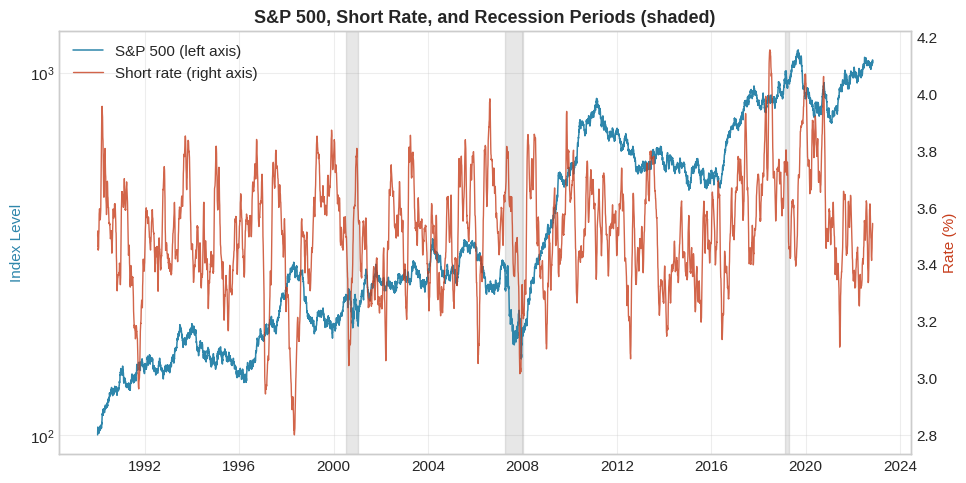

In [4]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.plot(sp500.index, sp500, color='#2E86AB', linewidth=1.1, label='S&P 500 (left axis)')
ax1.set_ylabel('Index Level', color='#2E86AB')
ax1.set_yscale('log')

ax2 = ax1.twinx()
ax2.plot(libor_s.index, libor_s * 100, color='#C73E1D', linewidth=1.0, alpha=0.8, label='Short rate (right axis)')
ax2.set_ylabel('Rate (%)', color='#C73E1D')
ax2.grid(False)

for _, row in recessions.iterrows():
    ax1.axvspan(row['start'], row['end'], color='#888888', alpha=0.2)

ax1.set_title('S&P 500, Short Rate, and Recession Periods (shaded)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.show()

## 4. Performance Statistics: Concept

Given a price series $P_t$ and a risk-free rate series, the standard toolkit for summarizing performance:

$$\text{Total Return} = \frac{P_T - P_0}{P_0} \qquad \text{Avg Ret} = \bar r \times 252 \qquad \text{Std} = s_r \times \sqrt{252}$$

$$\text{Sharpe Ratio} = \frac{\text{Avg Ret} - \overline{rfr}}{\text{Std}}$$

where $r_t = P_t/P_{t-1} - 1$ are simple daily returns, annualized by simple scaling (mean $\times$ 252 trading days, standard deviation $\times \sqrt{252}$, the square-root-of-time rule). The risk-free rate uses its own market convention (money-market rates like LIBOR are already quoted annualized, so no further scaling is applied here, unlike the equity return itself, which starts at daily frequency).

**Skewness** and **kurtosis** describe the shape of the return distribution beyond just its mean and spread: skewness of 0 and (excess) kurtosis of 0 match a normal distribution. Real equity returns are typically slightly negatively skewed (crashes are sharper than rallies) and strongly leptokurtic (fatter tails than normal, more extreme days than a Gaussian would predict), both of which the crash-period volatility built into Section 1's simulation reproduces.

**High Water Mark (HWM)** is simply the highest price ever reached; **Maximum Drawdown (MDD)** is covered in depth in Section 5.

In [5]:
def get_performance_stats(prices, rfr, label=None):
    BUS_DAYS = 252
    stats = pd.DataFrame(index=[label if label is not None else 0])

    ret = prices.pct_change()
    p0, p_last = prices.iloc[0], prices.iloc[-1]

    stats['Tot Ret'] = (p_last - p0) / p0
    stats['Avg Ret'] = ret.mean() * BUS_DAYS
    stats['rfr'] = rfr.mean()          # already an annualized rate in the source data
    stats['Std'] = ret.std() * np.sqrt(BUS_DAYS)
    stats['SR'] = (stats['Avg Ret'] - stats['rfr']) / stats['Std']
    stats['Skew'] = ret.skew()
    stats['Kurt'] = ret.kurtosis()

    hwm_date = prices.idxmax()
    stats['HWM'] = prices.max()
    stats['HWM date'] = hwm_date.date()

    dd = prices.cummax() - prices
    trough_date = dd.idxmax()
    peak_date = prices[:trough_date].idxmax()
    stats['MDD'] = 1 - prices[trough_date] / prices[peak_date]
    stats['Peak date'] = peak_date.date()
    stats['Trough date'] = trough_date.date()

    post_trough = prices[trough_date:]
    recovered = post_trough[post_trough >= prices[peak_date]]
    if len(recovered) > 0:
        rec_date = recovered.index[0]
        stats['Rec date'] = rec_date.date()
        stats['MDD dur'] = (rec_date - peak_date).days
    else:
        stats['Rec date'] = 'Yet to recover'
        stats['MDD dur'] = 'Yet to recover'

    return stats.T

stats = [
    get_performance_stats(sp500, libor_s, 'Full History'),
    get_performance_stats(sp500.loc['2014':'2017'], libor_s.loc['2014':'2017'], '2014-2017'),
    get_performance_stats(sp500.loc['2021'], libor_s.loc['2021'], '2021'),
    get_performance_stats(sp500.loc['2021':], libor_s.loc['2021':], '2021 to date'),
]
pd.set_option('display.width', 160)
stats_df = pd.concat(stats, axis=1)
print(stats_df)

               Full History   2014-2017            2021 2021 to date
Tot Ret            9.629361    0.476952        0.306373     0.403601
Avg Ret            0.084595    0.107044        0.273599     0.192113
rfr                0.035136    0.034709        0.034784     0.034546
Std                0.173526    0.159586        0.170357     0.165756
SR                 0.285023    0.453267        1.401849     0.950601
Skew              -0.058356    0.061706        0.062081     0.194505
Kurt               1.267359    0.005954         0.09888     -0.01421
HWM             1155.725783  919.219912     1015.480131  1102.292214
HWM date         2019-09-09  2017-10-24      2021-08-31   2022-07-01
MDD                0.371682    0.211894        0.111571     0.111571
Peak date        2019-09-09  2014-02-24      2021-08-31   2021-08-31
Trough date      2021-02-02  2015-01-21      2021-10-14   2021-10-14
Rec date     Yet to recover  2016-07-29  Yet to recover   2022-01-19
MDD dur      Yet to recover       

## 5. Maximum Drawdown: A Closer Look

The **drawdown** at time $t$ is the decline from the running historical peak to the current value:

$$\text{DD}(t) = \max\left\{0,\ \max_{\tau \in (0,t)} P(\tau) - P(t)\right\}$$

and the **maximum drawdown** over a window $[0,T]$ is the worst drawdown ever observed in that window:

$$\text{MDD}(T) = \max_{t \in (0,T)} \text{DD}(t)$$

Computing it is a running-maximum calculation: at every point, track the highest price seen so far (the running peak, `prices.cummax()`), and measure how far the current price has fallen from it. The single worst such gap, expressed as a proportion of the peak, is the MDD; the dates of that peak, the subsequent trough, and (if it happens within the sample) the eventual recovery back above the peak are all reported alongside it in `get_performance_stats()` above.

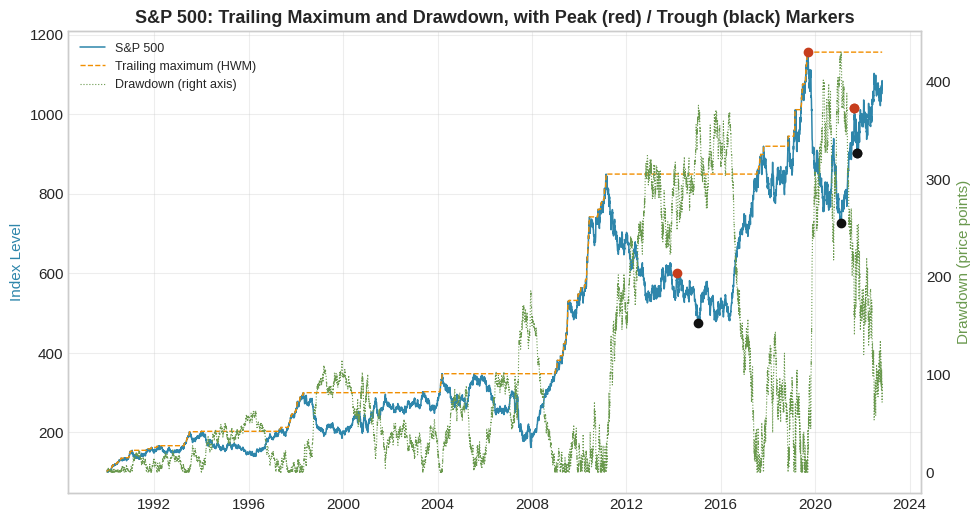

In [6]:
fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(sp500.index, sp500, color='#2E86AB', linewidth=1.1, label='S&P 500')

hwm = sp500.cummax()
ax1.plot(sp500.index, hwm, color='#F18F01', linewidth=1.0, linestyle='--', label='Trailing maximum (HWM)')

dd = hwm - sp500
ax2 = ax1.twinx()
ax2.plot(sp500.index, dd, color='#6A994E', linewidth=0.8, linestyle=':', label='Drawdown (right axis)')
ax2.set_ylabel('Drawdown (price points)', color='#6A994E')
ax2.grid(False)

# Mark peak/trough for each of the 4 reported sub-periods
for s in stats_df.columns:
    peak_d, trough_d = stats_df.loc['Peak date', s], stats_df.loc['Trough date', s]
    peak_ts, trough_ts = pd.Timestamp(peak_d), pd.Timestamp(trough_d)
    if peak_ts in sp500.index:
        ax1.plot(peak_ts, sp500[peak_ts], 'o', color='#C73E1D', markersize=6, zorder=5)
    if trough_ts in sp500.index:
        ax1.plot(trough_ts, sp500[trough_ts], 'o', color='#111111', markersize=6, zorder=5)

ax1.set_title('S&P 500: Trailing Maximum and Drawdown, with Peak (red) / Trough (black) Markers')
ax1.set_ylabel('Index Level', color='#2E86AB')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
plt.show()